# CineSense AI — Recommendation Performance Visualization & Analysis

## Objective

This notebook visualizes and analyzes the performance of the CineSense AI recommendation system.

The analysis focuses on:

- Baseline vs personalized recommendation models
- Precision@K
- Recall@K
- Hit Rate@K
- NDCG@K
- Performance across different values of K
- Recommendation coverage and diversity
- Interpretation of experimental results

The objective is not only to visualize model performance, but also to understand the strengths, limitations, and trade-offs of different recommendation strategies.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving model_comparison.csv to model_comparison.csv
Saving topk_evaluation.csv to topk_evaluation.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
model_comparison = pd.read_csv(
    "model_comparison.csv"
)

topk_evaluation = pd.read_csv(
    "topk_evaluation.csv"
)

print("Model Comparison Shape:",
      model_comparison.shape)

print("Top-K Evaluation Shape:",
      topk_evaluation.shape)

print("\nMODEL COMPARISON")
display(model_comparison)

print("\nTOP-K EVALUATION")
display(topk_evaluation)

Model Comparison Shape: (3, 5)
Top-K Evaluation Shape: (3, 5)

MODEL COMPARISON


,Model,Precision@10,Recall@10,Hit Rate@10,NDCG@10
0,Baseline,0.003800,0.037997,0.037997,0.017774
1,Basic Personalization,0.001727,0.017271,0.017271,0.010157
2,Improved Personalization,0.002591,0.025907,0.025907,0.011247



TOP-K EVALUATION


,K,Precision,Recall,Hit_Rate,NDCG
0,5,0.002763,0.013817,0.013817,0.007272
1,10,0.002591,0.025907,0.025907,0.011247
2,20,0.002159,0.043178,0.043178,0.015688


In [ ]:
print("Model Comparison Columns:")
print(model_comparison.columns.tolist())

print("\nTop-K Evaluation Columns:")
print(topk_evaluation.columns.tolist())

print("\nMissing Values — Model Comparison:")
print(model_comparison.isnull().sum())

print("\nMissing Values — Top-K Evaluation:")
print(topk_evaluation.isnull().sum())

Model Comparison Columns:
['Model', 'Precision@10', 'Recall@10', 'Hit Rate@10', 'NDCG@10']

Top-K Evaluation Columns:
['K', 'Precision', 'Recall', 'Hit_Rate', 'NDCG']

Missing Values — Model Comparison:
Model           0
Precision@10    0
Recall@10       0
Hit Rate@10     0
NDCG@10         0
dtype: int64

Missing Values — Top-K Evaluation:
K            0
Precision    0
Recall       0
Hit_Rate     0
NDCG         0
dtype: int64


In [ ]:
model_percent = model_comparison.copy()

metric_columns = [
    "Precision@10",
    "Recall@10",
    "Hit Rate@10",
    "NDCG@10"
]

model_percent[metric_columns] = (
    model_percent[metric_columns] * 100
)

display(
    model_percent.style.format({
        "Precision@10": "{:.2f}%",
        "Recall@10": "{:.2f}%",
        "Hit Rate@10": "{:.2f}%",
        "NDCG@10": "{:.2f}%"
    })
)

,Model,Precision@10,Recall@10,Hit Rate@10,NDCG@10
0,Baseline,0.38%,3.80%,3.80%,1.78%
1,Basic Personalization,0.17%,1.73%,1.73%,1.02%
2,Improved Personalization,0.26%,2.59%,2.59%,1.12%


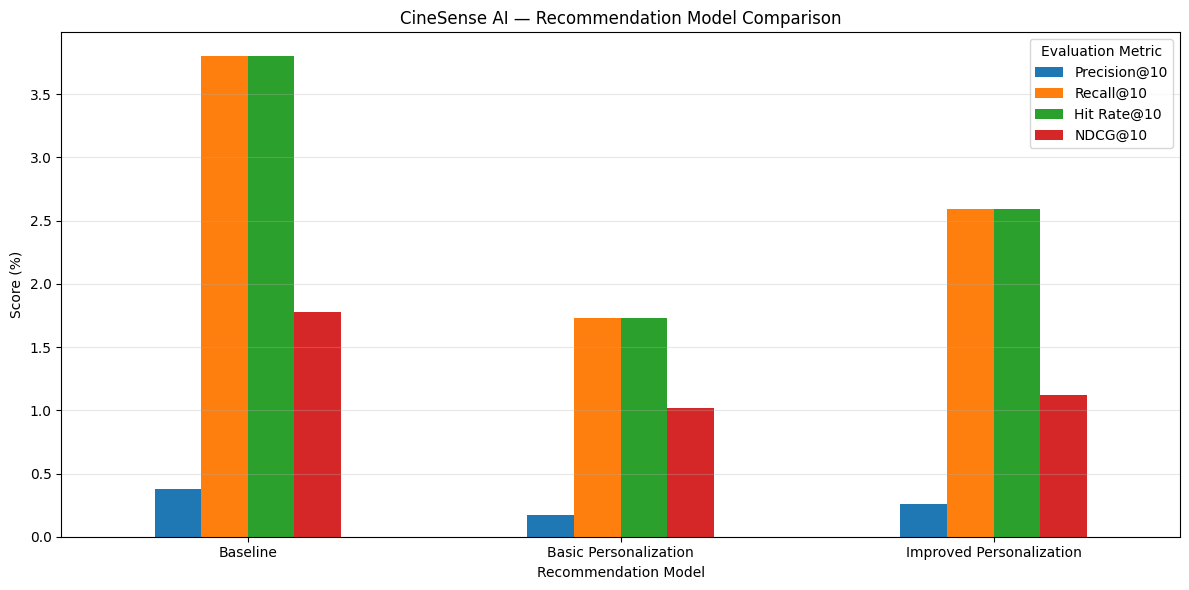

In [ ]:
plot_data = model_percent.set_index("Model")

ax = plot_data[
    [
        "Precision@10",
        "Recall@10",
        "Hit Rate@10",
        "NDCG@10"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "CineSense AI — Recommendation Model Comparison"
)

plt.xlabel("Recommendation Model")
plt.ylabel("Score (%)")

plt.xticks(
    rotation=0
)

plt.legend(
    title="Evaluation Metric"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

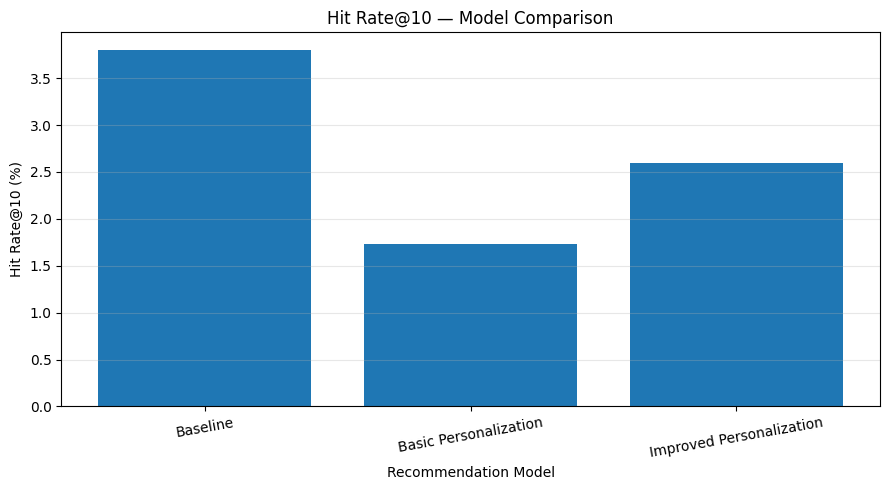

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    model_percent["Model"],
    model_percent["Hit Rate@10"]
)

plt.title(
    "Hit Rate@10 — Model Comparison"
)

plt.xlabel("Recommendation Model")
plt.ylabel("Hit Rate@10 (%)")

plt.xticks(rotation=10)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

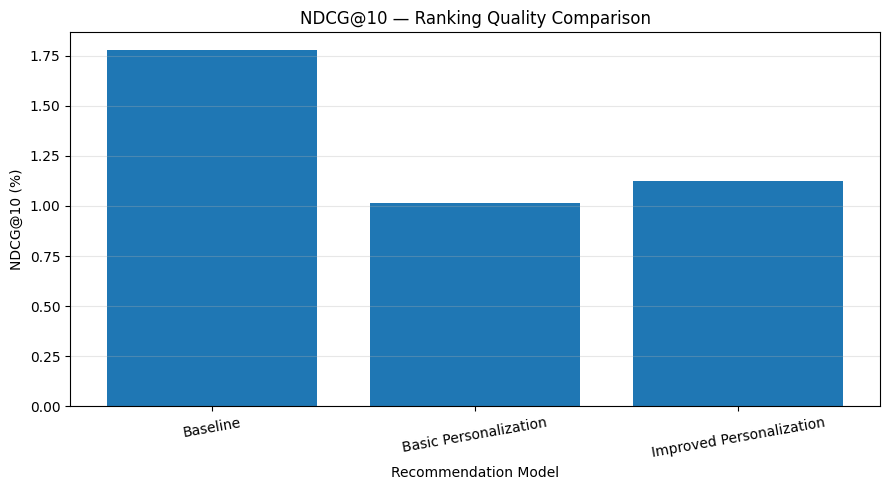

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    model_percent["Model"],
    model_percent["NDCG@10"]
)

plt.title(
    "NDCG@10 — Ranking Quality Comparison"
)

plt.xlabel("Recommendation Model")
plt.ylabel("NDCG@10 (%)")

plt.xticks(rotation=10)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
display(topk_evaluation)

,K,Precision,Recall,Hit_Rate,NDCG
0,5,0.002763,0.013817,0.013817,0.007272
1,10,0.002591,0.025907,0.025907,0.011247
2,20,0.002159,0.043178,0.043178,0.015688


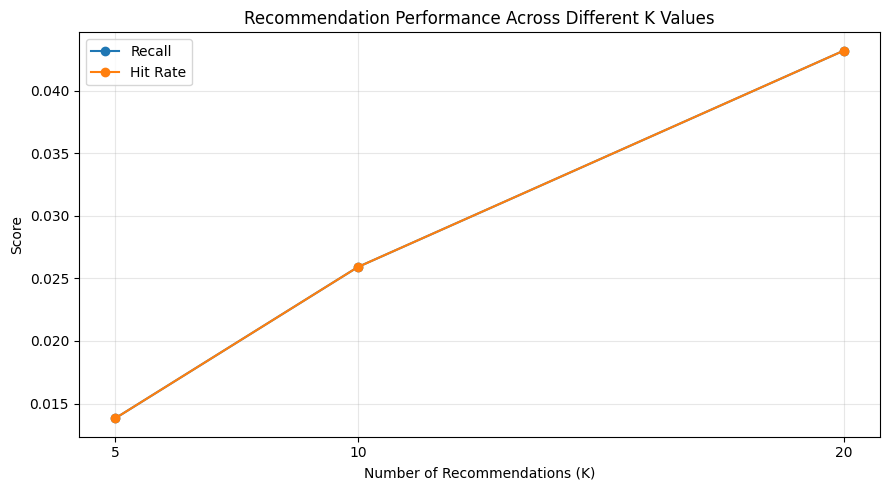

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    topk_evaluation["K"],
    topk_evaluation["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    topk_evaluation["K"],
    topk_evaluation["Hit_Rate"],
    marker="o",
    label="Hit Rate"
)

plt.title(
    "Recommendation Performance Across Different K Values"
)

plt.xlabel("Number of Recommendations (K)")
plt.ylabel("Score")

plt.xticks(
    topk_evaluation["K"]
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

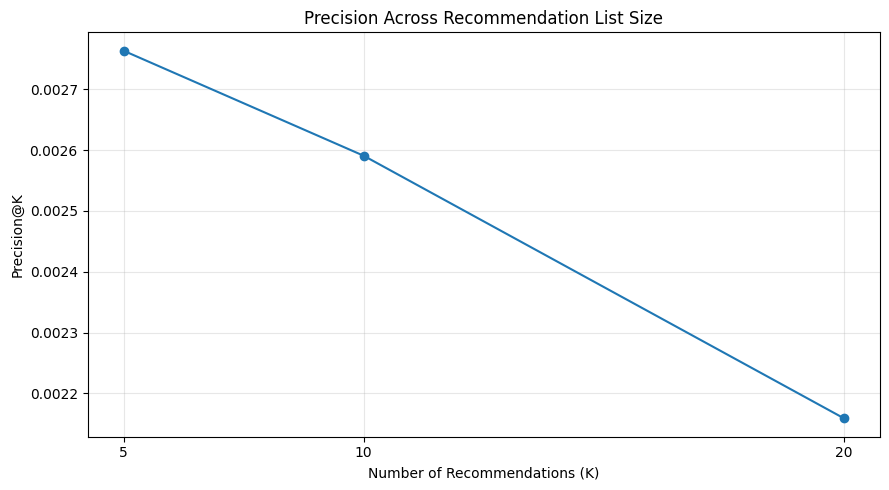

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    topk_evaluation["K"],
    topk_evaluation["Precision"],
    marker="o"
)

plt.title(
    "Precision Across Recommendation List Size"
)

plt.xlabel("Number of Recommendations (K)")
plt.ylabel("Precision@K")

plt.xticks(
    topk_evaluation["K"]
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
baseline_row = model_comparison[
    model_comparison["Model"] == "Baseline"
].iloc[0]

comparison_analysis = []

for _, row in model_comparison.iterrows():

    if row["Model"] == "Baseline":
        continue

    result = {
        "Model": row["Model"]
    }

    for metric in metric_columns:

        baseline_value = baseline_row[metric]
        model_value = row[metric]

        if baseline_value != 0:
            change = (
                (model_value - baseline_value)
                / baseline_value
            ) * 100
        else:
            change = 0

        result[f"{metric} Change (%)"] = change

    comparison_analysis.append(result)

improvement_df = pd.DataFrame(comparison_analysis)

display(
    improvement_df.style.format({
        col: "{:+.2f}%"
        for col in improvement_df.columns
        if "Change" in col
    })
)

,Model,Precision@10 Change (%),Recall@10 Change (%),Hit Rate@10 Change (%),NDCG@10 Change (%)
0,Basic Personalization,-54.55%,-54.55%,-54.55%,-42.86%
1,Improved Personalization,-31.82%,-31.82%,-31.82%,-36.72%


In [ ]:
print("BEST MODEL BY EVALUATION METRIC")
print("=" * 45)

for metric in metric_columns:

    best_index = model_comparison[metric].idxmax()

    best_model = model_comparison.loc[
        best_index,
        "Model"
    ]

    best_score = model_comparison.loc[
        best_index,
        metric
    ]

    print(
        f"{metric:<18} -> "
        f"{best_model} "
        f"({best_score * 100:.2f}%)"
    )

BEST MODEL BY EVALUATION METRIC
Precision@10       -> Baseline (0.38%)
Recall@10          -> Baseline (3.80%)
Hit Rate@10        -> Baseline (3.80%)
NDCG@10            -> Baseline (1.78%)


In [ ]:
topk_percent = topk_evaluation.copy()

for column in [
    "Precision",
    "Recall",
    "Hit_Rate",
    "NDCG"
]:
    topk_percent[column] = (
        topk_percent[column] * 100
    )

display(
    topk_percent.style.format({
        "Precision": "{:.2f}%",
        "Recall": "{:.2f}%",
        "Hit_Rate": "{:.2f}%",
        "NDCG": "{:.2f}%"
    })
)

,K,Precision,Recall,Hit_Rate,NDCG
0,5,0.28%,1.38%,1.38%,0.73%
1,10,0.26%,2.59%,2.59%,1.12%
2,20,0.22%,4.32%,4.32%,1.57%


In [ ]:
best_recall_k = topk_evaluation.loc[
    topk_evaluation["Recall"].idxmax(),
    "K"
]

best_precision_k = topk_evaluation.loc[
    topk_evaluation["Precision"].idxmax(),
    "K"
]

best_ndcg_k = topk_evaluation.loc[
    topk_evaluation["NDCG"].idxmax(),
    "K"
]

print("TOP-K ANALYSIS")
print("=" * 35)

print(
    "Highest Precision achieved at K =",
    int(best_precision_k)
)

print(
    "Highest Recall achieved at K =",
    int(best_recall_k)
)

print(
    "Highest NDCG achieved at K =",
    int(best_ndcg_k)
)

TOP-K ANALYSIS
Highest Precision achieved at K = 5
Highest Recall achieved at K = 20
Highest NDCG achieved at K = 20


In [ ]:
summary_metrics = model_percent[
    [
        "Model",
        "Precision@10",
        "Recall@10",
        "Hit Rate@10",
        "NDCG@10"
    ]
].copy()

display(
    summary_metrics.style.format({
        "Precision@10": "{:.2f}%",
        "Recall@10": "{:.2f}%",
        "Hit Rate@10": "{:.2f}%",
        "NDCG@10": "{:.2f}%"
    })
)

,Model,Precision@10,Recall@10,Hit Rate@10,NDCG@10
0,Baseline,0.38%,3.80%,3.80%,1.78%
1,Basic Personalization,0.17%,1.73%,1.73%,1.02%
2,Improved Personalization,0.26%,2.59%,2.59%,1.12%


## Experimental Interpretation

The offline evaluation demonstrates that recommendation quality cannot be judged only by adding more personalization signals.

The baseline model provides a useful reference point based primarily on global movie quality and popularity. The initial personalized model incorporates historical genre preferences, while the improved personalized model introduces confidence-weighted genre preferences to reduce the influence of genres supported by very little user history.

The experiments show that personalization does not necessarily improve every ranking metric. This can occur because genre-level preferences provide only a coarse representation of user taste. Two movies belonging to the same genre can still be very different in theme, style, cast, narrative, and user appeal.

The leave-one-out evaluation also creates a difficult retrieval problem: the system must recover one specific hidden movie from a catalog containing thousands of candidates.

Precision, Recall, Hit Rate, and NDCG therefore provide complementary views of recommendation performance rather than a single definition of model quality.

The Top-K experiments further demonstrate the trade-off between recommendation-list size and retrieval performance. Increasing K gives the system more opportunities to retrieve a relevant item, while smaller recommendation lists are more selective.

These findings motivate future improvements such as collaborative filtering, latent user/movie representations, richer metadata features, semantic embeddings, and learned ranking models.

## Context-Aware Validation

In addition to offline ranking evaluation, CineSense AI was tested for contextual constraint satisfaction.

During the context-aware tests:

- Preferred Genre Match Rate: 100%
- Avoided Genre Success Rate: 100%
- High-Rating Recommendation Rate: 80%
- Custom Context Recommendation Quality: 93.33%
- Recommendation Change Rate across two contrasting contexts: 100%

These values measure contextual behavior and constraint satisfaction, not offline retrieval accuracy. Therefore, they are reported separately from Precision@K, Recall@K, Hit Rate@K, and NDCG@K.

In [ ]:
improvement_df.to_csv(
    "model_improvement_analysis.csv",
    index=False
)

summary_metrics.to_csv(
    "evaluation_summary.csv",
    index=False
)

topk_percent.to_csv(
    "topk_evaluation_percent.csv",
    index=False
)

print("Saved successfully:")
print("1. model_improvement_analysis.csv")
print("2. evaluation_summary.csv")
print("3. topk_evaluation_percent.csv")

Saved successfully:
1. model_improvement_analysis.csv
2. evaluation_summary.csv
3. topk_evaluation_percent.csv


In [ ]:
from google.colab import files

files.download(
    "model_improvement_analysis.csv"
)

files.download(
    "evaluation_summary.csv"
)

files.download(
    "topk_evaluation_percent.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>